In [1]:
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from folium.plugins import HeatMap
import folium
import os
from folium.plugins import HeatMap
import folium

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/VDI/')

['gowalla_friendship.csv',
 'gowalla_spots_subset1.csv',
 'gowalla_userinfo.csv',
 'gowalla_checkins.csv',
 'gowalla_spots_subset2.csv']

In [4]:
# Load the uploaded data files
checkins_path = '/content/drive/MyDrive/VDI/gowalla_checkins.csv'
friendship_path = '/content/drive/MyDrive/VDI/gowalla_friendship.csv'
spots1_path = '/content/drive/MyDrive/VDI/gowalla_spots_subset1.csv'
spots2_path = '/content/drive/MyDrive/VDI/gowalla_spots_subset2.csv'
userinfo_path = '/content/drive/MyDrive/VDI/gowalla_userinfo.csv'

# Reload datasets with appropriate delimiter and handle malformed lines
checkins = pd.read_csv(checkins_path, delimiter=';', on_bad_lines='skip')
friendship = pd.read_csv(friendship_path, delimiter=';', on_bad_lines='skip')
spots1 = pd.read_csv(spots1_path, delimiter=';', on_bad_lines='skip')
spots2 = pd.read_csv(spots2_path, delimiter=';', encoding='latin1', on_bad_lines='skip')
userinfo = pd.read_csv(userinfo_path, delimiter=';', on_bad_lines='skip')

# Clean datasets by dropping rows with missing values
checkins_cleaned = checkins.dropna()
friendship_cleaned = friendship.dropna()
spots1_cleaned = spots1.dropna()
spots2_cleaned = spots2.dropna()
userinfo_cleaned = userinfo.dropna()

# Displaying the first few rows of each cleaned dataset to confirm success
checkins_cleaned.head(), friendship_cleaned.head(), spots1_cleaned.head(), spots2_cleaned.head(), userinfo_cleaned.head()

(   userid  placeid              datetime
 0    1338   482954  2011-06-23T02:24:22Z
 1    1338   580963  2011-06-22T14:23:03Z
 2    1338   365256  2011-06-09T23:29:30Z
 3    1338    89504  2011-05-22T15:54:30Z
 4    1338  1267135  2011-05-21T16:51:13Z,
    userid1  userid2
 0        1    63488
 1        1        2
 2        1        3
 3        1        4
 4        1        5,
      id            created_at                 lng              lat  \
 0  8904  2008-12-06T16:28:53Z    -946.074.986.458  390.523.183.095   
 1  8932  2008-12-13T02:16:51Z    -972.543.561.459  329.276.616.668   
 2  8936  2008-12-14T22:08:39Z    -945.919.954.777  390.533.181.067   
 3  8938  2008-12-15T00:22:49Z      -9.459.031.105  390.528.237.667   
 4  8947  2008-12-16T23:14:05Z  -1.220.296.311.378  373.318.803.266   
 
    photos_count  checkins_count  users_count  radius_meters  highlights_count  \
 0             0             114           21             35                 0   
 1             2            

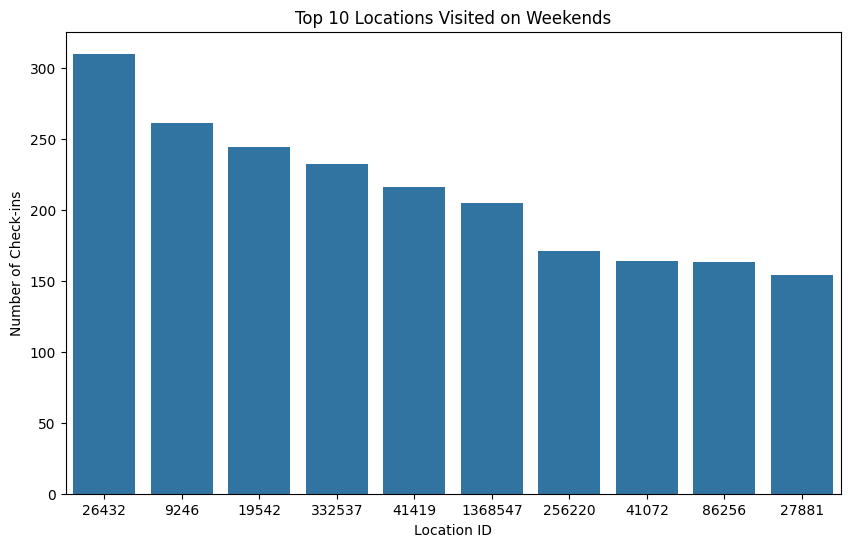

In [5]:
# --- Visualization 1: Locations visited at specific times (weekend or night) ---
checkins_cleaned['datetime'] = pd.to_datetime(checkins_cleaned['datetime'])
checkins_cleaned['hour'] = checkins_cleaned['datetime'].dt.hour
checkins_cleaned['dayofweek'] = checkins_cleaned['datetime'].dt.dayofweek

weekend_checkins = checkins_cleaned[checkins_cleaned['dayofweek'] >= 5]
night_checkins = checkins_cleaned[(checkins_cleaned['hour'] >= 18) | (checkins_cleaned['hour'] < 6)]

plt.figure(figsize=(10, 6))
sns.countplot(data=weekend_checkins, x='placeid', order=weekend_checkins['placeid'].value_counts().iloc[:10].index)
plt.title('Top 10 Locations Visited on Weekends')
plt.xlabel('Location ID')
plt.ylabel('Number of Check-ins')
plt.show()

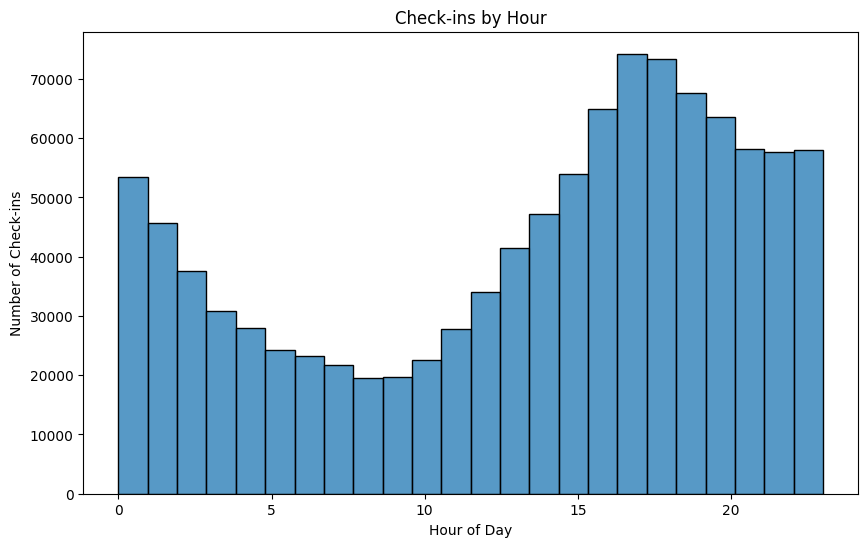

In [6]:
# --- Visualization 2: Check-ins by Hour ---
checkins_cleaned['hour'] = checkins_cleaned['datetime'].dt.hour
plt.figure(figsize=(10, 6))
sns.histplot(checkins_cleaned['hour'], bins=24, kde=False)
plt.title("Check-ins by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Check-ins")
plt.show()

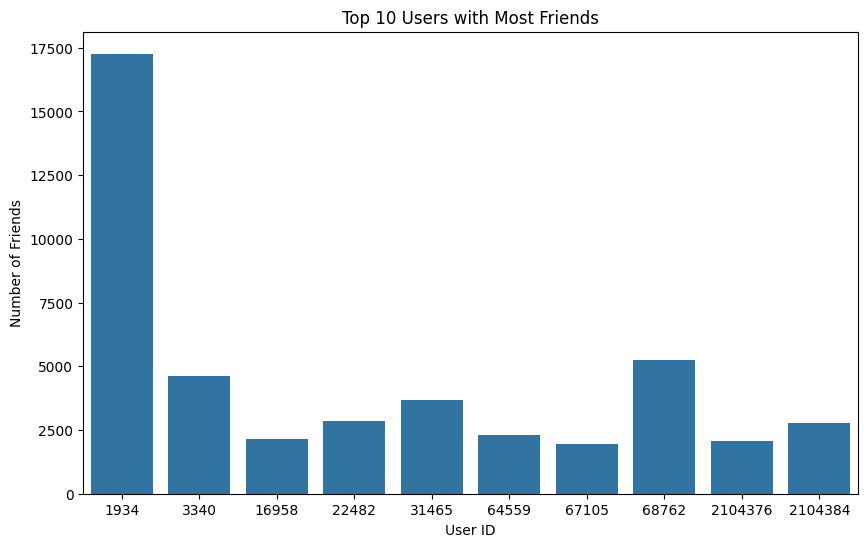

In [7]:
# --- Visualization 3: User with the most friends ---
friend_counts = friendship_cleaned['userid1'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=friend_counts.iloc[:10].index, y=friend_counts.iloc[:10].values)
plt.title('Top 10 Users with Most Friends')
plt.xlabel('User ID')
plt.ylabel('Number of Friends')
plt.show()

        placeid  checkin_count
99833    332537            991
5434      19542            840
255863  1368547            671
156        9246            655
78688    245559            602
88901    288983            585
15329     41419            583
8328      25678            548
15227     41072            548
106189   360592            529


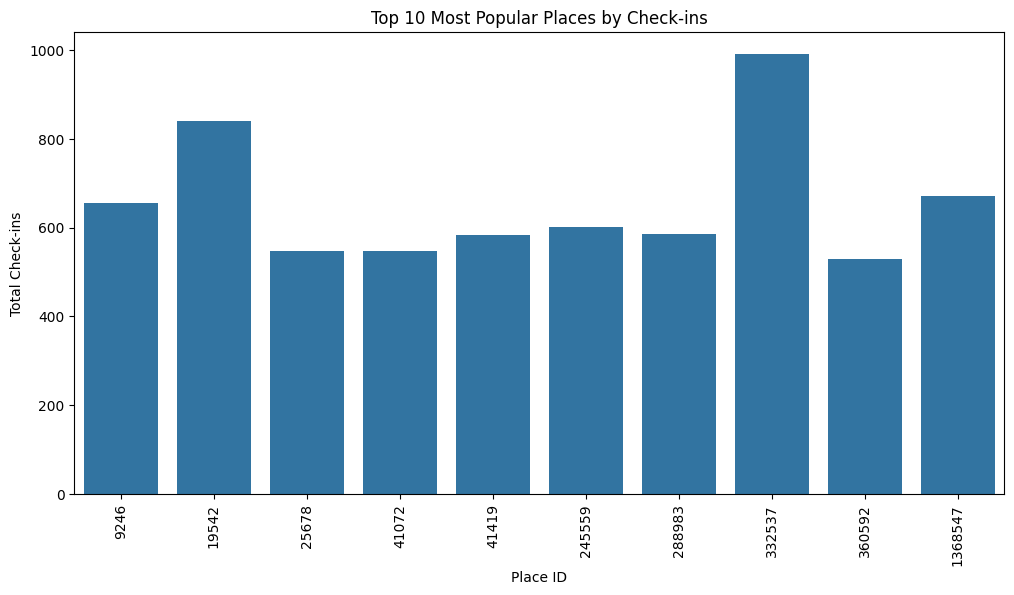

In [8]:
# --- Visualization 4: Most popular locations based on check-ins ---
# Menggunakan dataset checkins_cleaned untuk menghitung check-in berdasarkan 'placeid'
popular_places = checkins_cleaned.groupby('placeid')['userid'].count().reset_index()

# Mengganti nama kolom untuk kejelasan
popular_places.columns = ['placeid', 'checkin_count']

# Mengurutkan tempat berdasarkan jumlah check-in terbanyak
top_10_places = popular_places.sort_values(by='checkin_count', ascending=False).head(10)

# Menampilkan 10 tempat paling populer
print(top_10_places)

# Visualisasi 10 tempat paling populer
plt.figure(figsize=(12, 6))
sns.barplot(x='placeid', y='checkin_count', data=top_10_places)
plt.title('Top 10 Most Popular Places by Check-ins')
plt.xlabel('Place ID')
plt.ylabel('Total Check-ins')
plt.xticks(rotation=90)
plt.show()

           Category  Count
0  Gas & Automotive  40747
1  Corporate Office  32926
2             Asian  31708
3           Grocery  27228
4       Coffee Shop  24862
5     Other - Food   24707
6          American  24129
7  Other - Shopping  23098
8           Mexican  20335
9             Pizza  18033


<ipython-input-9-ba72ef03b6f7>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Category', data=category_table, palette='viridis')


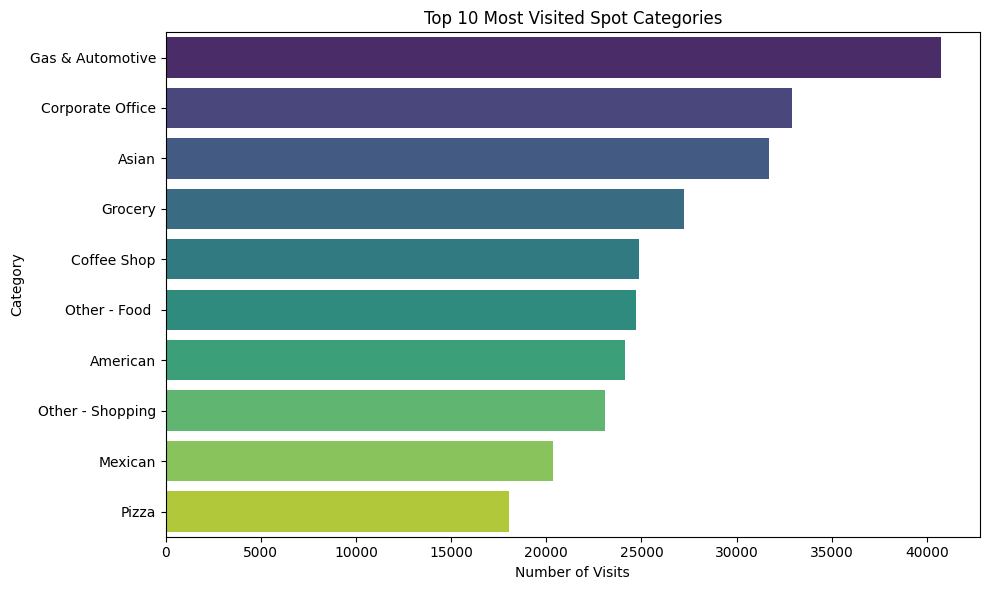

In [9]:
# --- Visualization 5: Most Visited Spot Categories ---
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ekstraksi nama kategori dari kolom 'spot_categories'
spots1_cleaned['spot_categories'] = spots1_cleaned['spot_categories'].apply(
    lambda x: ast.literal_eval(x)[0]['name'] if pd.notna(x) and isinstance(ast.literal_eval(x), list) and len(ast.literal_eval(x)) > 0 else None
)

# 2. Mengubah list kategori menjadi baris terpisah untuk masing-masing kategori
categories_expanded = spots1_cleaned.explode('spot_categories')

# 3. Menghitung frekuensi kemunculan tiap kategori
category_counts = categories_expanded['spot_categories'].value_counts()

# 4. Membuat tabulasi (tabel frekuensi kategori)
category_table = pd.DataFrame({'Category': category_counts.index, 'Count': category_counts.values}).head(10)

# Menampilkan tabulasi
print(category_table)

# 5. Visualisasi menggunakan bar plot untuk 10 kategori teratas
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Category', data=category_table, palette='viridis')
plt.title('Top 10 Most Visited Spot Categories')
plt.xlabel('Number of Visits')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [10]:
# Combine the two spot datasets
spots_cleaned = pd.concat([spots1_cleaned, spots2_cleaned], ignore_index=True)

# Merge check-ins with spots for spatial analysis
merged_data = pd.merge(checkins_cleaned, spots_cleaned, left_on='placeid', right_on='id', suffixes=('_checkin', '_spot'))

# Ensure latitude and longitude columns are numeric
merged_data['lat'] = pd.to_numeric(merged_data['lat'], errors='coerce')
merged_data['lng'] = pd.to_numeric(merged_data['lng'], errors='coerce')

# Remove rows with invalid coordinates
map_data = merged_data.dropna(subset=['lat', 'lng'])

# Create output directory
output_dir = "/mnt/data/visualizations"
os.makedirs(output_dir, exist_ok=True)

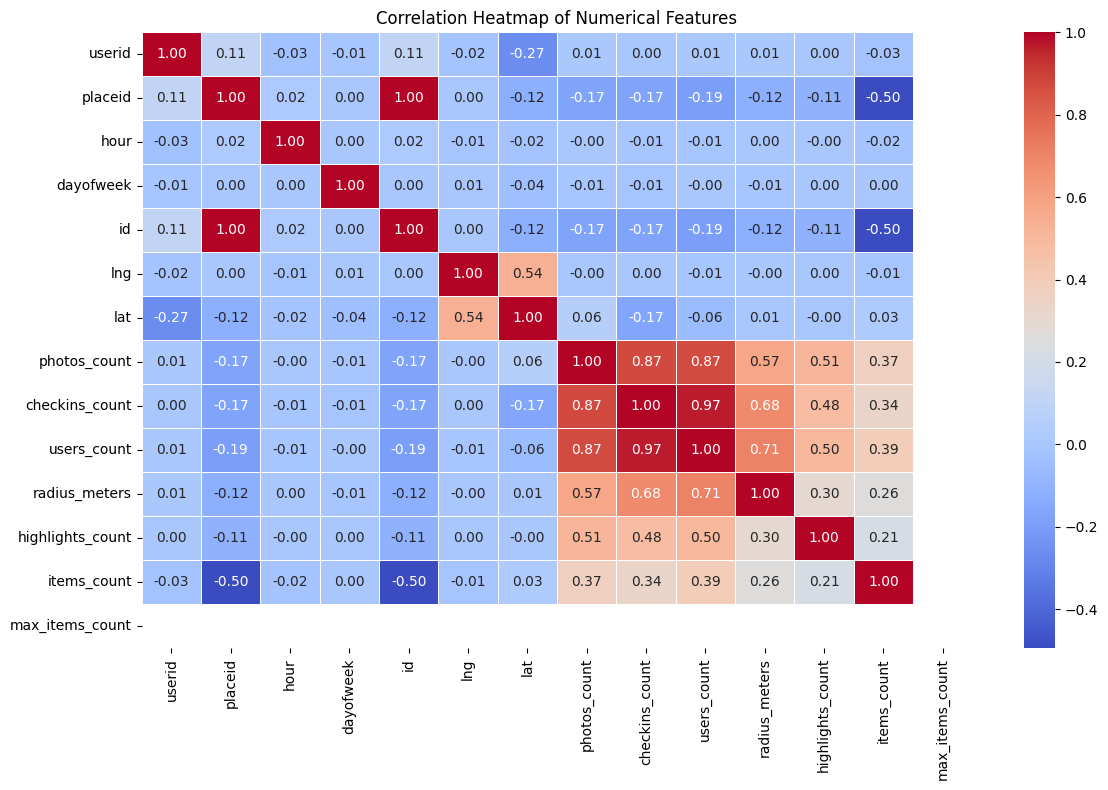

In [11]:
# --- Visualization 6: Correlation Heatmap of Numerical Features ---
numerical_features = merged_data.select_dtypes(include=['number'])
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()  # Pastikan tata letak rapi
plt.show()  # Menampilkan gambar visualisasi langsung

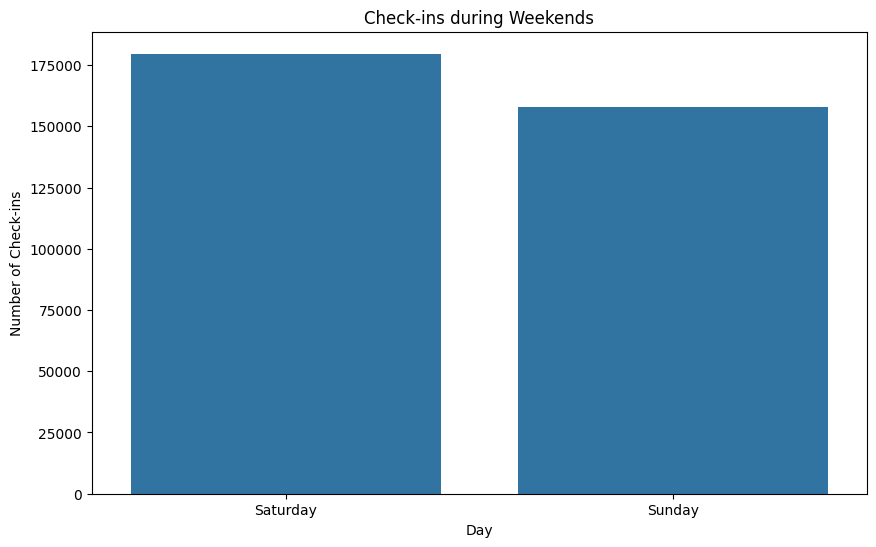

In [12]:
# --- Visualization 7: Time analysis: Visits during weekends ---
checkins_cleaned['datetime'] = pd.to_datetime(checkins_cleaned['datetime'], errors='coerce')
checkins_cleaned['weekday'] = checkins_cleaned['datetime'].dt.day_name()
weekend_data = checkins_cleaned[checkins_cleaned['weekday'].isin(['Saturday', 'Sunday'])]
plt.figure(figsize=(10, 6))
sns.countplot(x='weekday', data=weekend_data, order=['Saturday', 'Sunday'])
plt.title("Check-ins during Weekends")
plt.xlabel("Day")
plt.ylabel("Number of Check-ins")
weekend_image = os.path.join(output_dir, "weekend_checkins.png")
plt.savefig(weekend_image)
plt.show()

In [14]:
import seaborn as sns
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
os.listdir('/content/drive/MyDrive/Dataset VDI/')
path = '/content/drive/MyDrive/Dataset VDI/Book1.xlsx'
data = pd.read_excel(path)

            city_state  checkin_num
804         Austin, TX     298805.0
14148        Stockholm     274389.0
10202     New York, NY     208374.0
6877           Jakarta     195666.0
10843             Oslo     144641.0
12318           Riyadh     129548.0
13286            Seoul     123572.0
8589   Los Angeles, CA     122208.0
14815            Tokyo     117573.0
9761            Moscow      94818.0


<ipython-input-15-5a2f44dc3cda>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city_state', y='checkin_num', data=top_10_places_by_city_state, palette='viridis')


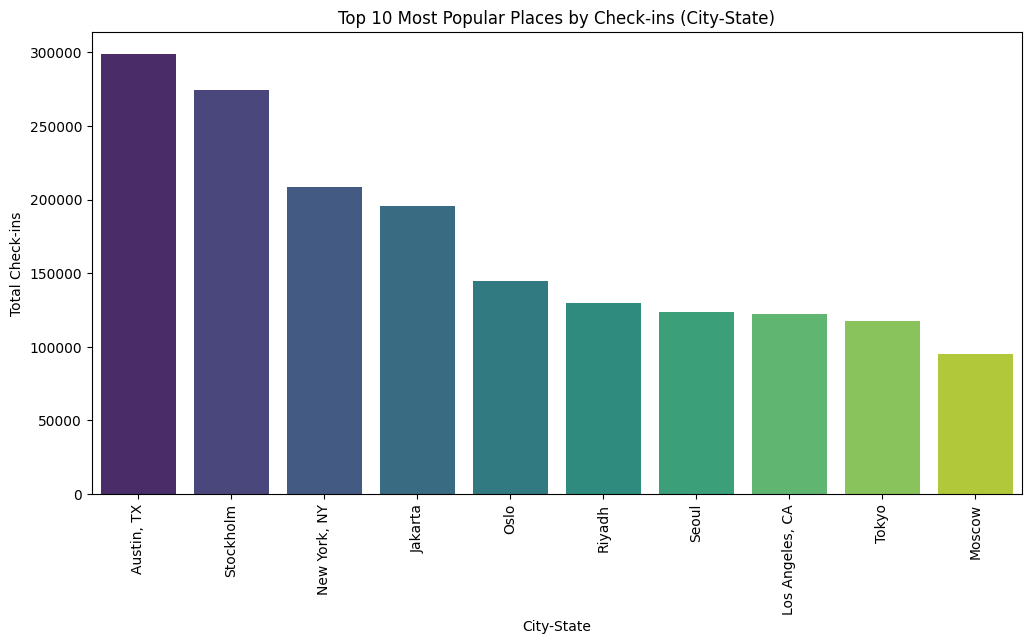

In [15]:
# --- Visualization 8: Top 10 Most Popular Places by Check-ins (City-State) ---
# Menghitung jumlah check-in berdasarkan 'city_state'
popular_places_by_city_state = data.groupby('city_state')['checkin_num'].sum().reset_index()

# Mengurutkan tempat berdasarkan jumlah check-in terbanyak
top_10_places_by_city_state = popular_places_by_city_state.sort_values(by='checkin_num', ascending=False).head(10)

# Menampilkan 10 tempat paling populer berdasarkan 'city_state'
print(top_10_places_by_city_state)

# Visualisasi 10 tempat paling populer berdasarkan 'city_state'
plt.figure(figsize=(12, 6))
sns.barplot(x='city_state', y='checkin_num', data=top_10_places_by_city_state, palette='viridis')
plt.title('Top 10 Most Popular Places by Check-ins (City-State)')
plt.xlabel('City-State')
plt.ylabel('Total Check-ins')
plt.xticks(rotation=90)
plt.show()

In [16]:
pip install folium networkx matplotlib

In [ ]:
import networkx as nx
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import pandas as pd

# --- Visualization 9: Social Network Based on Check-ins ---
# 1. Membangun graf berdasarkan check-in yang sama
G = nx.Graph()

# Menambahkan edges antar pengguna yang check-in di tempat yang sama
for place in data['placeid'].unique():
    # Mengambil pengguna yang check-in di tempat yang sama
    users_at_place = data[data['placeid'] == place]['userid'].unique()

    # Menambahkan edges antar pengguna yang ada di tempat yang sama
    for i in range(len(users_at_place)):
        for j in range(i + 1, len(users_at_place)):
            G.add_edge(users_at_place[i], users_at_place[j])

# 2. Menentukan lokasi untuk plotting (menggunakan lat/lng dari data yang ada)
latitude = data['lat'].mean()  # Rata-rata latitude untuk lokasi peta
longitude = data['lng'].mean()  # Rata-rata longitude untuk lokasi peta

# 3. Membuat peta dengan folium, menambahkan atribut
map_center = [latitude, longitude]  # Titik pusat peta
mymap = folium.Map(
    location=map_center,
    zoom_start=12,
    tiles='Stamen Terrain',
    attr='Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap, under ODbL.'
)

# 4. Menambahkan MarkerCluster untuk pengguna yang check-in di lokasi yang sama
marker_cluster = MarkerCluster().add_to(mymap)

# Menambahkan marker untuk setiap tempat (menggunakan lat dan lng)
for _, row in data.iterrows():
    folium.Marker([row['lat'], row['lng']], popup=f"User: {row['userid']}").add_to(marker_cluster)

# 5. Visualisasi peta
mymap.save("social_network_map.html")  # Simpan peta ke file HTML
print("Peta telah disimpan sebagai 'social_network_map.html'. Silakan buka file ini di browser.")

# 6. Visualisasi Jaringan Sosial
# Membuat visualisasi graf untuk hubungan antar pengguna
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)  # Menentukan posisi node
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='skyblue', alpha=0.6)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
plt.title('Social Network Based on Check-ins')
plt.axis('off')
plt.show()

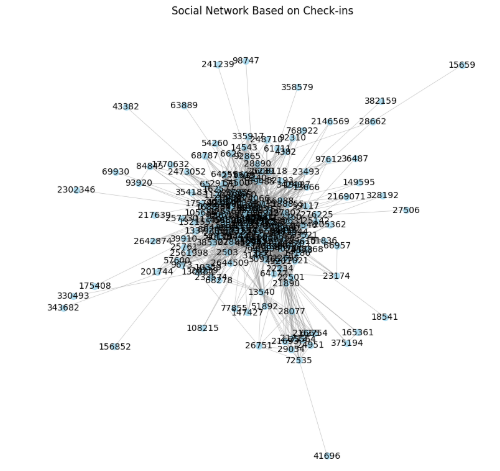

In [ ]:
# --- Visualization 10: Spatial Distribution of Check-ins ---
import geopandas as gpd
from shapely.geometry import Point

# Membuat kolom untuk koordinat geospasial (lng, lat)
data['geometry'] = data.apply(lambda row: Point(row['lng'], row['lat']), axis=1)


# Membuat GeoDataFrame
gdf = gpd.GeoDataFrame(data, geometry='geometry')


# Visualisasi distribusi spasial check-in berdasarkan kategori
# Asumsi kita sudah memiliki kolom kategori, bisa berdasarkan data yang ada
# Misalnya kolom 'spot_categories' yang berisi list kategori tempat


# Melakukan unnesting kategori tempat
data['categories'] = data['spot_categories'].apply(lambda x: [item['name'] for item in eval(x)] if isinstance(x, str) else [])
categories = data.explode('categories')


# Menghitung jumlah check-in per kategori
category_checkins = categories.groupby('categories')['checkin_num'].sum().reset_index()
# Menampilkan kategori dengan check-in terbanyak
print(category_checkins)


# Visualisasi distribusi spasial
ax = gdf.plot(marker='o', color='blue', markersize=5, figsize=(10, 10))
plt.title('Spatial Distribution of Check-ins')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

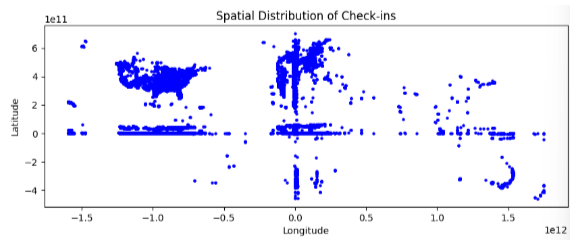